<a href="https://colab.research.google.com/github/apcyssr/2026_Spring_KBU/blob/main/20260320_%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B4%80%EB%A6%AC%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

csv_url = 'https://raw.githubusercontent.com/ancestor9/data/main/customers.csv'
df = pd.read_csv(csv_url)
display(df)

,고객ID,성별,결제수단,거주지,회원등급,만족도,최근접속시간(시),선호제품군_적정온도,나이,구매수량,총결제금액
0,CUST_0001,남성,휴대폰결제,대구,Gold,2,1,27.0,34,7,760355
1,CUST_0002,여성,계좌이체,대구,Gold,5,15,24.6,20,42,727001
2,CUST_0003,여성,신용카드,광주,Gold,1,6,20.3,51,8,618787
3,CUST_0004,여성,계좌이체,서울,VVIP,5,20,16.8,19,29,434545
4,CUST_0005,여성,계좌이체,광주,Gold,3,6,23.5,53,45,604750
...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST_9996,여성,간편결제,대구,Gold,3,14,21.2,59,3,934416
9996,CUST_9997,여성,휴대폰결제,경기,Silver,5,13,21.6,48,4,417516
9997,CUST_9998,여성,휴대폰결제,부산,VIP,3,23,25.9,59,31,163234
9998,CUST_9999,기타,휴대폰결제,서울,Gold,4,20,24.0,24,38,986091


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   고객ID        10000 non-null  object 
 1   성별          10000 non-null  object 
 2   결제수단        10000 non-null  object 
 3   거주지         10000 non-null  object 
 4   회원등급        10000 non-null  object 
 5   만족도         10000 non-null  int64  
 6   최근접속시간(시)   10000 non-null  int64  
 7   선호제품군_적정온도  10000 non-null  float64
 8   나이          10000 non-null  int64  
 9   구매수량        10000 non-null  int64  
 10  총결제금액       10000 non-null  int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 859.5+ KB
None


In [11]:
display(df.describe(include='object'))

,고객ID,성별,결제수단,거주지,회원등급
count,10000,10000,10000,10000,10000
unique,10000,3,4,5,5
top,CUST_9984,여성,계좌이체,경기,Silver
freq,1,3400,2548,2069,2043


In [12]:
summary_df = pd.DataFrame({
    'Column': df.columns,
    'DataType': df.dtypes,
    'Non-Null Count': df.count(),
    'Unique Values': [df[col].nunique() if df[col].dtype == 'object' else '-' for col in df.columns],
    'Top Value (Categorical)': [df[col].mode()[0] if df[col].dtype == 'object' else '-' for col in df.columns],
    'Mean (Numerical)': [df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else '-' for col in df.columns],
    'Std (Numerical)': [df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else '-' for col in df.columns],
    'Min (Numerical)': [df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else '-' for col in df.columns],
    'Max (Numerical)': [df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else '-' for col in df.columns]
})

display(summary_df)

,Column,DataType,Non-Null Count,Unique Values,Top Value (Categorical),Mean (Numerical),Std (Numerical),Min (Numerical),Max (Numerical)
고객ID,고객ID,object,10000,10000,CUST_0001,-,-,-,-
성별,성별,object,10000,3,여성,-,-,-,-
결제수단,결제수단,object,10000,4,계좌이체,-,-,-,-
거주지,거주지,object,10000,5,경기,-,-,-,-
회원등급,회원등급,object,10000,5,Silver,-,-,-,-
만족도,만족도,int64,10000,-,-,2.998,1.416685,1,5
최근접속시간(시),최근접속시간(시),int64,10000,-,-,11.5655,6.926363,0,23
선호제품군_적정온도,선호제품군_적정온도,float64,10000,-,-,19.95989,5.01381,0.4,39.6
나이,나이,int64,10000,-,-,44.479,15.014696,19,70
구매수량,구매수량,int64,10000,-,-,25.7012,14.483484,1,50


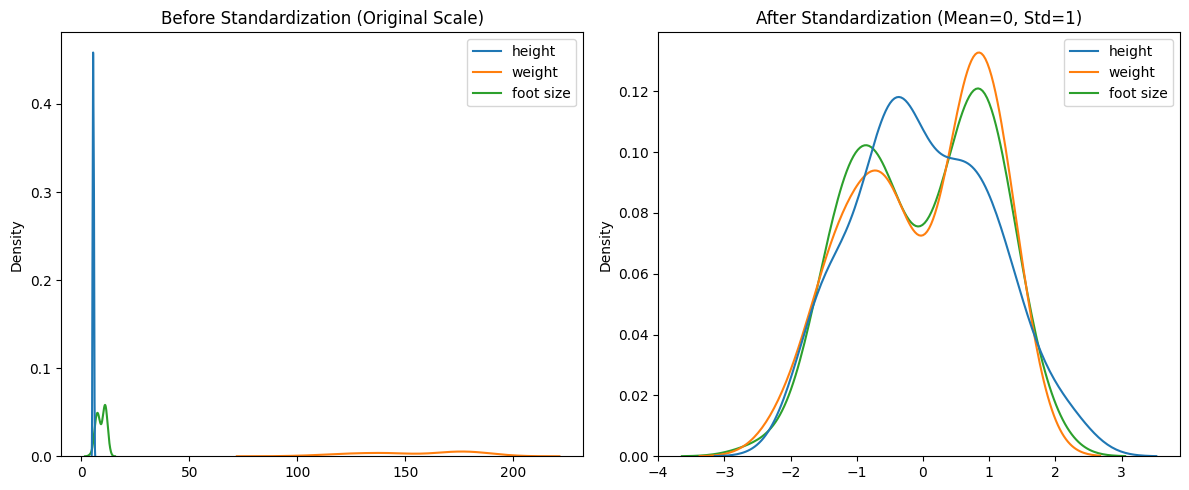

--- 표준화 후 통계 ---
       height  weight  foot size
count  100.00  100.00     100.00
mean    -0.00   -0.00      -0.00
std      1.01    1.01       1.01
min     -1.94   -2.17      -2.44
25%     -0.63   -0.81      -0.85
50%     -0.14    0.30       0.16
75%      0.69    0.88       0.90
max      2.33    1.48       1.86


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. URL에서 데이터를 로드합니다
url = "https://raw.githubusercontent.com/ancestor9/data/main/human_data.csv"
df = pd.read_csv(url)

# 필요한 열만 선택합니다 (Height, Weight, Foot Size)
# 참고: 실제 CSV 파일에서 열 이름을 다시 확인해야 할 수 있습니다
# height, weight, foot size 열이 있다고 가정합니다 (원래 'foot size')
cols_to_scale = ['height', 'weight', 'foot size'] # 'income'을 'foot size'로 변경했습니다
data = df[cols_to_scale]

# 2. 표준화 (Z-score Scaling) 수행
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 그래프를 쉽게 그릴 수 있도록 DataFrame으로 다시 변환합니다
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale)

# 3. 전후 데이터 비교 (시각화)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 전 그래프: 단위가 많이 다릅니다
sns.kdeplot(data=data, ax=ax1)
ax1.set_title('Before Standardization (Original Scale)')

# 후 그래프: 모든 변수가 평균 0, 표준편차 1을 갖습니다
sns.kdeplot(data=df_scaled, ax=ax2)
ax2.set_title('After Standardization (Mean=0, Std=1)')

plt.tight_layout()
plt.show()

# 표준화 후 통계값을 확인합니다
print("--- 표준화 후 통계 ---")
print(df_scaled.describe().round(2))

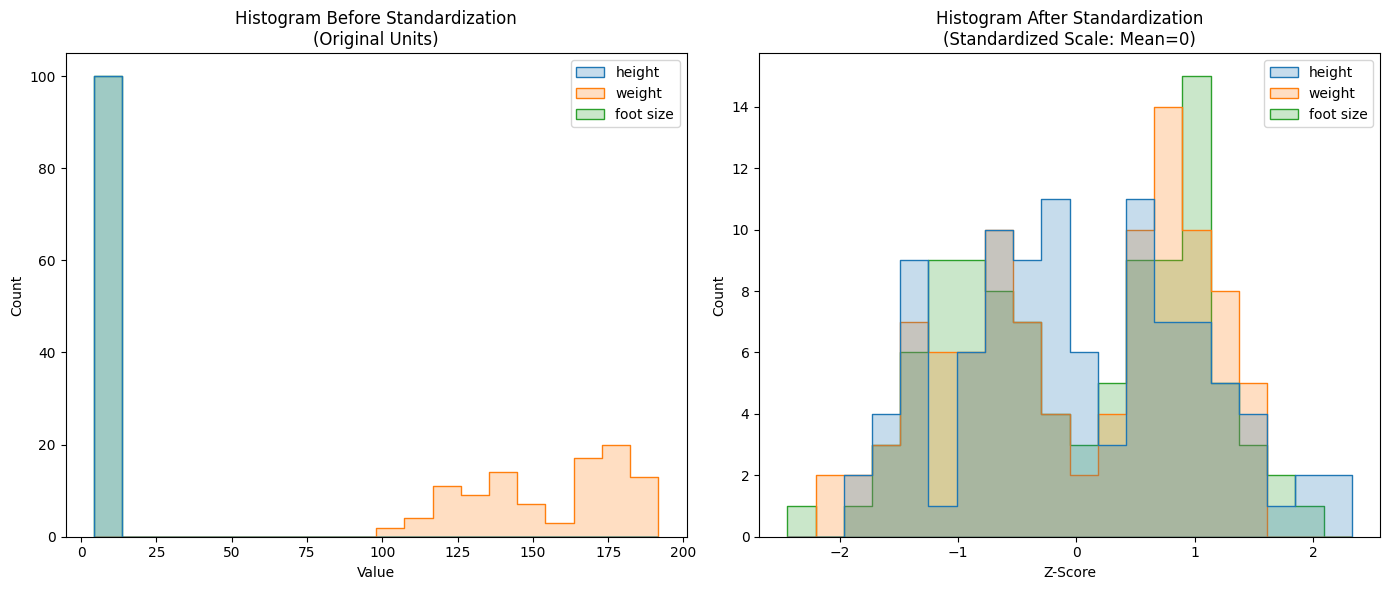

--- 표준화 전 평균값 ---
height         5.6210
weight       155.2210
foot size      9.3236
dtype: float64

--- 표준화 후 평균값 (0에 가까워야 함) ---
height      -0.0
weight      -0.0
foot size   -0.0
dtype: float64


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. URL에서 데이터를 로드합니다
url = "https://raw.githubusercontent.com/ancestor9/data/main/human_data.csv"
df = pd.read_csv(url)

# 필요한 열만 선택합니다 (height, weight, foot size)
cols_to_scale = ['height', 'weight', 'foot size']
data = df[cols_to_scale]

# 2. 표준화 (Standardization) 수행
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale)

# 3. 히스토그램 시각화 및 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 표준화 전 히스토그램: 변수마다 단위(Scale)가 다름
sns.histplot(data=data, bins=20, kde=False, ax=ax1, element="step")
ax1.set_title('Histogram Before Standardization\n(Original Units)')
ax1.set_xlabel('Value')

# 표준화 후 히스토그램: 모든 변수가 평균 0 근처로 모임
sns.histplot(data=df_scaled, bins=20, kde=False, ax=ax2, element="step")
ax2.set_title('Histogram After Standardization\n(Standardized Scale: Mean=0)')
ax2.set_xlabel('Z-Score')

plt.tight_layout()
plt.show()

# 통계 수치 비교 출력
print("--- 표준화 전 평균값 ---")
print(data.mean())
print("\n--- 표준화 후 평균값 (0에 가까워야 함) ---")
print(df_scaled.mean().round(4))

1. 'diamonds' 데이터셋을 로드하는 중...

2. 원본 'price' 데이터의 왜도 계산
Original Price skewness = 1.62

3. 변환된 데이터의 왜도 계산
Log-transformed Price skewness = 0.12
Square Root-transformed Price skewness = 0.84
Box-Cox-transformed Price skewness = 0.03

4. 히스토그램 시각화 중...


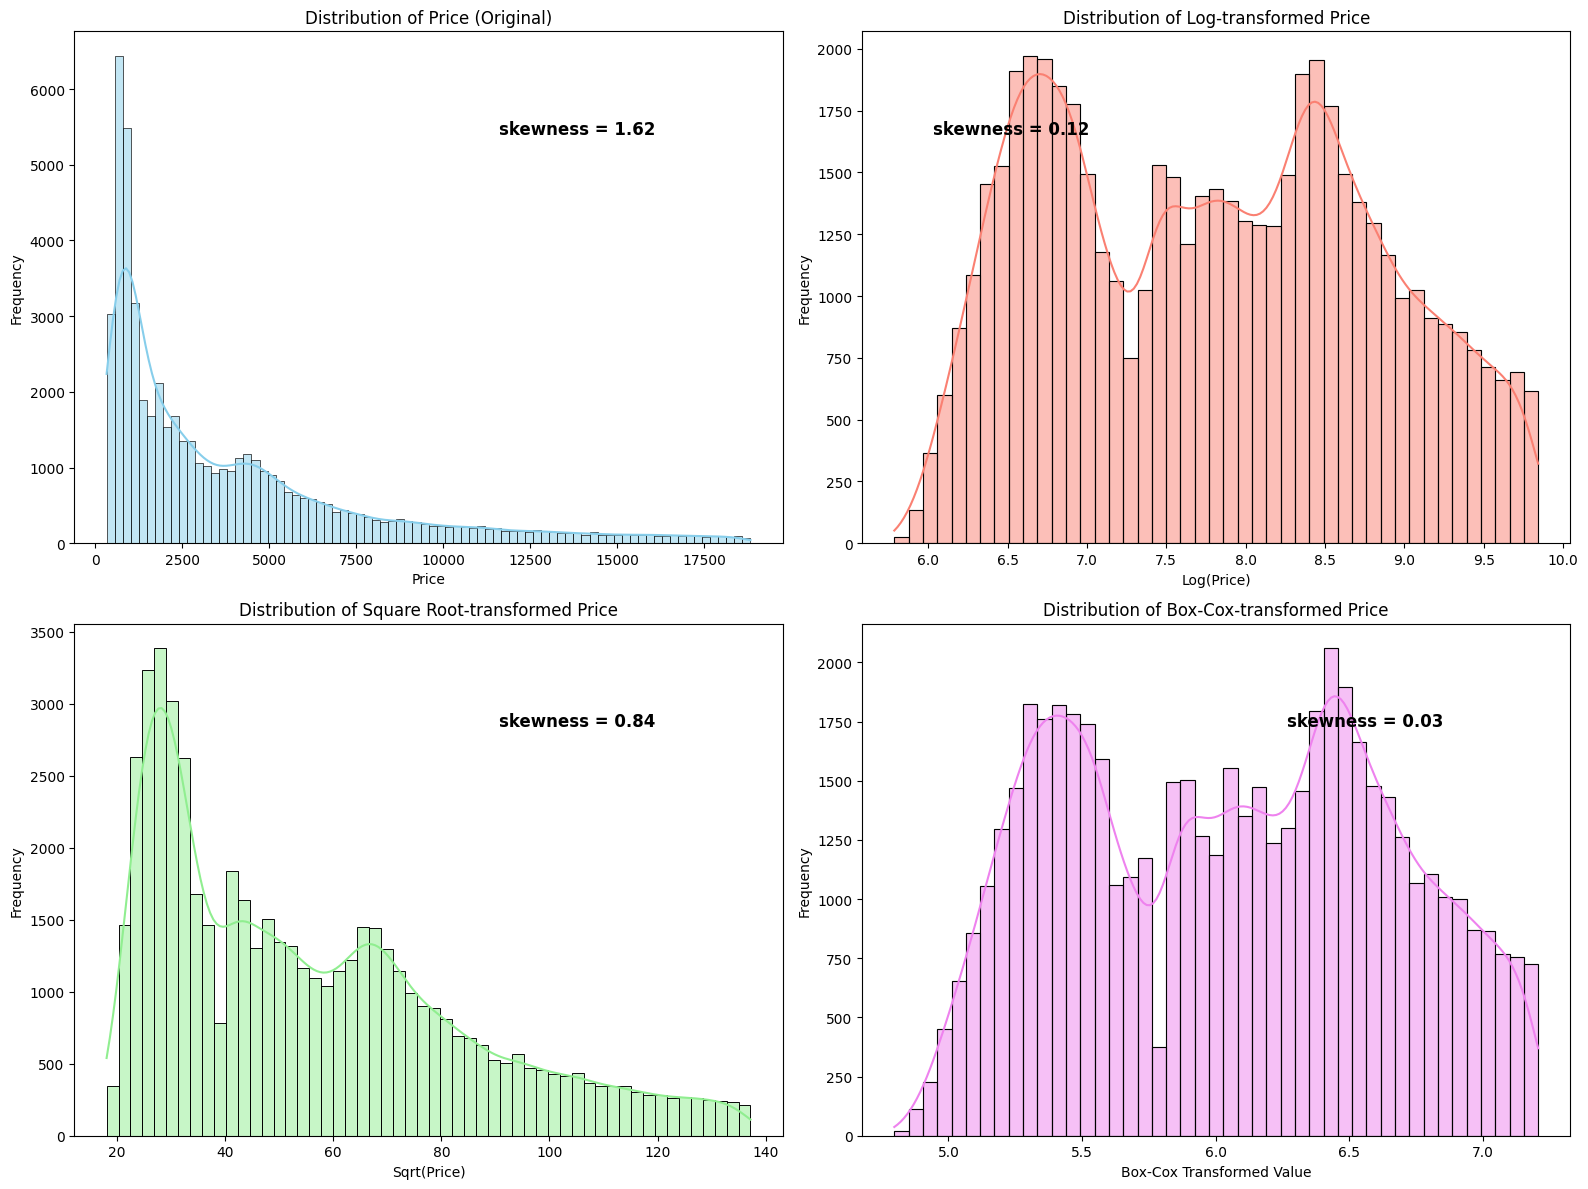


완료되었습니다.


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import boxcox # Box-Cox 변환을 위해 필요

# matplotlib의 한글 폰트 설정 (필요한 경우 주석 해제하여 사용)
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows, Malgun Gothic 사용

# 1. 'diamonds' 데이터셋 로드
print("1. 'diamonds' 데이터셋을 로드하는 중...")
df = sns.load_dataset("diamonds")

# 분석할 price 변수 추출
price_data = df['price']

# 2. 원본 데이터의 왜도(skewness) 구하기
print("\n2. 원본 'price' 데이터의 왜도 계산")
original_skew = price_data.skew()
print(f"Original Price skewness = {original_skew:.2f}")

# 3. 데이터 변환 (Transformation)

# ① 로그 변환 (Log Transformation)
# np.log1p를 사용하면 x가 0일 때의 무한대 문제를 방지할 수 있습니다 (x+1에 로그).
# diamonds 데이터는 price가 모두 양수이므로 np.log도 괜찮습니다.
log_price_data = np.log(price_data)

# ② 루트 변환 (Square Root Transformation)
sqrt_price_data = np.sqrt(price_data)

# ③ 박스-콕스 변환 (Box-Cox Transformation)
# Box-Cox는 입력 데이터가 엄격하게 양수여야 합니다. (price는 양수이므로 가능)
# 반환값은 (transformed_data, lambda) 인데, data 부분만 사용합니다.
boxcox_price_data, _ = boxcox(price_data)

# 4. 변환된 데이터의 왜도 계산
print("\n3. 변환된 데이터의 왜도 계산")
log_skew = log_price_data.skew()
sqrt_skew = sqrt_price_data.skew()
# numpy array 형태이므로 pandas Series로 감싸서 .skew() 사용
boxcox_skew = pd.Series(boxcox_price_data).skew()

print(f"Log-transformed Price skewness = {log_skew:.2f}")
print(f"Square Root-transformed Price skewness = {sqrt_skew:.2f}")
print(f"Box-Cox-transformed Price skewness = {boxcox_skew:.2f}")

# 5. 그래프 시각화 (서브플롯 생성)

print("\n4. 히스토그램 시각화 중...")
# 2행 2열 구조의 서브플롯 설정
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 원본 데이터 히스토그램 (Original) ---
sns.histplot(price_data, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Price (Original)')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
# 왜도 값을 그래프 주석으로 추가
axes[0, 0].annotate(f'skewness = {original_skew:.2f}',
                    xy=(0.6, 0.8), xycoords='axes fraction',
                    fontsize=12, fontweight='bold')

# --- 로그 변환 데이터 히스토그램 (Log) ---
sns.histplot(log_price_data, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Log-transformed Price')
axes[0, 1].set_xlabel('Log(Price)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].annotate(f'skewness = {log_skew:.2f}',
                    xy=(0.1, 0.8), xycoords='axes fraction',
                    fontsize=12, fontweight='bold')

# --- 루트 변환 데이터 히스토그램 (Square Root) ---
sns.histplot(sqrt_price_data, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Square Root-transformed Price')
axes[1, 0].set_xlabel('Sqrt(Price)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].annotate(f'skewness = {sqrt_skew:.2f}',
                    xy=(0.6, 0.8), xycoords='axes fraction',
                    fontsize=12, fontweight='bold')

# --- 박스-콕스 변환 데이터 히스토그램 (Box-Cox) ---
sns.histplot(boxcox_price_data, kde=True, ax=axes[1, 1], color='violet')
axes[1, 1].set_title('Distribution of Box-Cox-transformed Price')
axes[1, 1].set_xlabel('Box-Cox Transformed Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].annotate(f'skewness = {boxcox_skew:.2f}',
                    xy=(0.6, 0.8), xycoords='axes fraction',
                    fontsize=12, fontweight='bold')

# 그래프 간격 조절
plt.tight_layout()
plt.show()

print("\n완료되었습니다.")

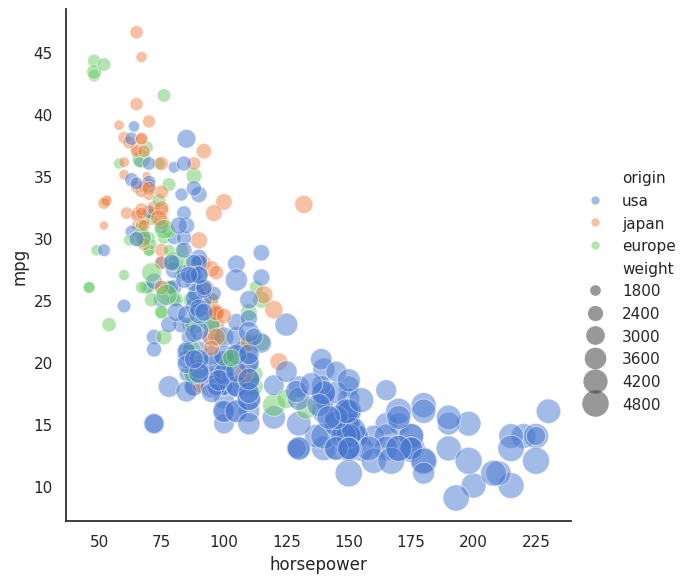

In [22]:
import seaborn as sns
sns.set_theme(style="white")
# Load the example mpg dataset
mpg = sns.load_dataset("mpg")
# Plot miles per gallon against horsepower with other semantics
sns.relplot(
x="horsepower",
y="mpg",
hue="origin",
size="weight",
sizes=(40, 400),
alpha=.5,
palette="muted",
height=6,
data=mpg
)


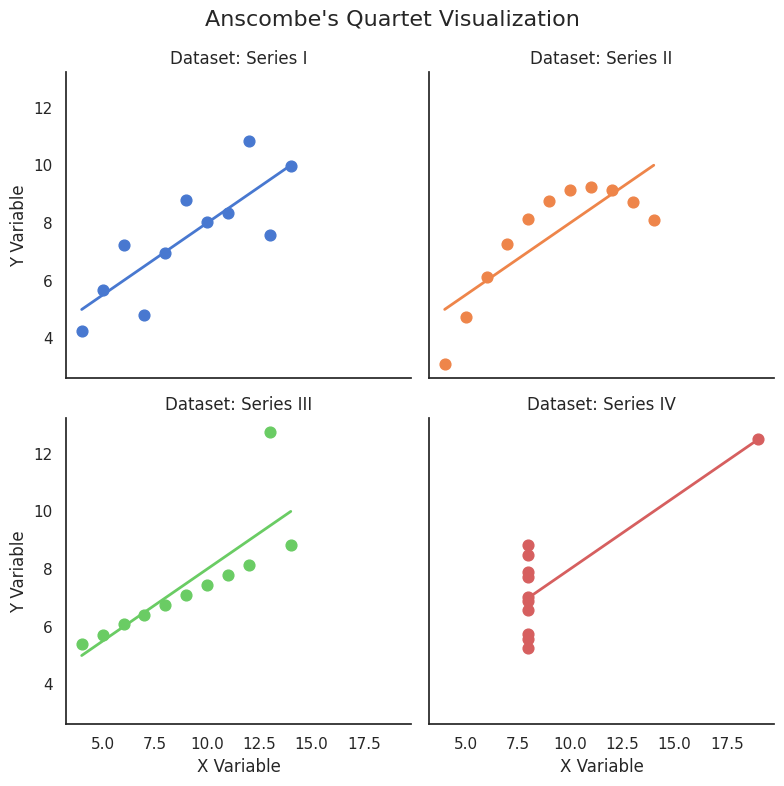

--- [그룹별 X, Y 변수의 평균 및 표준편차] ---
          X                   Y          
       mean       std      mean       std
Series                                   
I       9.0  3.316625  7.500000  2.032890
II      9.0  3.316625  7.500909  2.031657
III     9.0  3.316625  7.500000  2.030424
IV      9.0  3.316625  7.500909  2.030579

--- [그룹별 X와 Y의 상관계수] ---
Series
I      0.816186
II     0.816237
III    0.816287
IV     0.816521
dtype: float64


/tmp/ipykernel_1178/1871420207.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('Series').apply(lambda g: g['X'].corr(g['Y'])))


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Colab의 sample_data 폴더에서 anscombe.json 파일을 로드합니다
file_path = '/content/sample_data/anscombe.json'
df = pd.read_json(file_path)

# 2. 시각화 설정: 'Series' 컬럼을 기준으로 2x2 레이아웃 생성
# hue="Series"를 사용하여 그룹별로 색상을 다르게 지정합니다
g = sns.lmplot(x="X", y="Y", col="Series", hue="Series", data=df,
               col_wrap=2, ci=None, palette="muted", height=4,
               scatter_kws={"s": 60, "alpha": 1},
               line_kws={"lw": 2})

# 3. 그래프의 축 레이블과 제목을 영어(English)로 설정
g.set_axis_labels("X Variable", "Y Variable")
g.set_titles("Dataset: Series {col_name}")

# 4. 그래프 레이아웃 다듬기 및 출력
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Anscombe's Quartet Visualization", fontsize=16)
plt.tight_layout()
plt.show()

# 5. 통계 수치 출력 (콘솔 출력 부분은 한국어 유지)
print("--- [그룹별 X, Y 변수의 평균 및 표준편차] ---")
print(df.groupby('Series').agg(['mean', 'std']))

print("\n--- [그룹별 X와 Y의 상관계수] ---")
print(df.groupby('Series').apply(lambda g: g['X'].corr(g['Y'])))

In [26]:
# scikit-learn을 사용하여 직접 가져오기
from sklearn.datasets import fetch_openml

# blood-transfusion-service-center 데이터셋 로드 (ID: 1464)
dataset = fetch_openml(data_id=1464, as_frame=True, parser='auto')
df = dataset.frame

# 데이터 확인
print(df.head())

   V1  V2     V3  V4 Class
0   2  50  12500  98     2
1   0  13   3250  28     2
2   1  16   4000  35     2
3   2  20   5000  45     2
4   1  24   6000  77     1


Fetching dataset from OpenML...

--- [Descriptive Statistics: V1] ---
Mean: 9.6067
Median: 7.1000
Skewness: 1.8805
Kurtosis: 9.3913
Std Dev: 8.0954


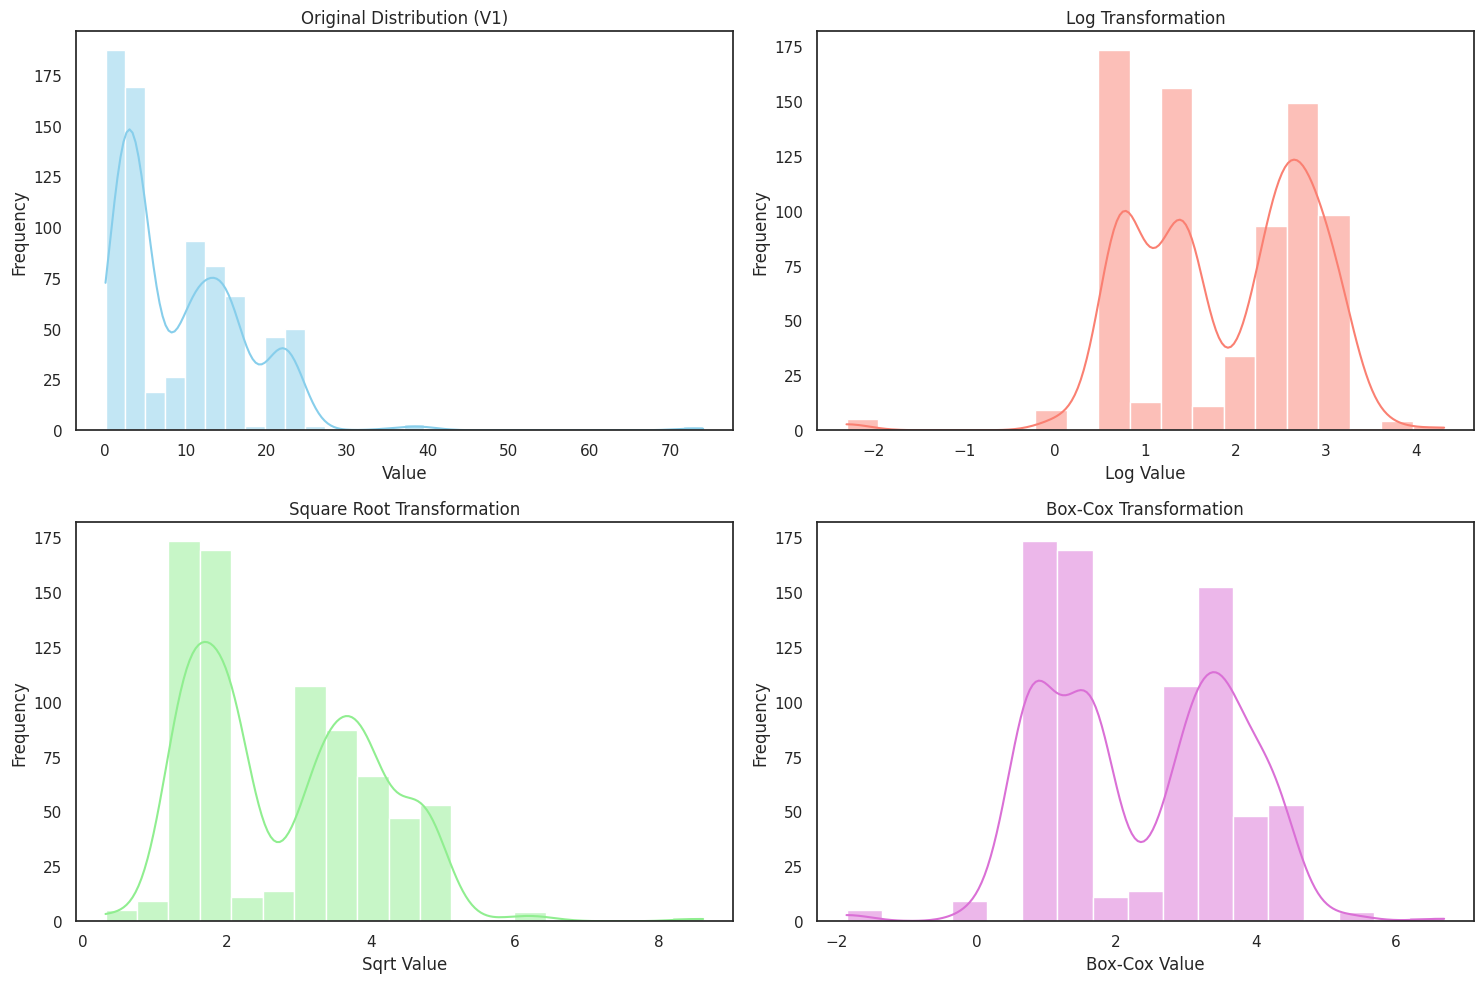

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from scipy.stats import boxcox

# 1. 데이터 로드 (sklearn의 fetch_openml 사용)
# OpenML 라이브러리 대신 sklearn을 사용하여 안정성을 높였습니다.
try:
    # 'blood-transfusion-service-center' 데이터셋 로드 (ID: 1464)
    # parser='auto'를 설정하여 최신 버전의 호환성을 유지합니다.
    print("Fetching dataset from OpenML...")
    dataset = fetch_openml(data_id=1464, as_frame=True, parser='auto')
    df = dataset.frame

    # 분석을 위해 타겟(Class)을 제외한 특성 데이터 중 첫 번째 열 선택
    # 보통 V1 (Recency) 열이 선택됩니다.
    target_col = df.columns[0]

except Exception as e:
    print(f"Error fetching data: {e}")
    # 로컬 파일에서 읽어오는 예비 코드 (GitHub 사용자를 위한 안내)
    # df = pd.read_csv("blood_transfusion.csv")
    print("Notice: Using fallback dummy data for visualization.")
    df = pd.DataFrame({'V1': np.random.exponential(scale=2, size=500)})
    target_col = 'V1'

# 데이터 전처리: 로그 및 박스-콕스 변환을 위해 양수로 보정 (0이 있으면 안 됨)
data = df[target_col] + 0.1

# 2. 통계 분석 결과 출력 (Console Output)
print(f"\n--- [Descriptive Statistics: {target_col}] ---")
stats = {
    "Mean": data.mean(),
    "Median": data.median(),
    "Skewness": data.skew(),
    "Kurtosis": data.kurt(),
    "Std Dev": data.std()
}
for key, value in stats.items():
    print(f"{key}: {value:.4f}")

# 3. 데이터 시각화 (Graph Output in English)
plt.figure(figsize=(15, 10))

# Original Data
plt.subplot(2, 2, 1)
sns.histplot(data, kde=True, color='skyblue')
plt.title(f'Original Distribution ({target_col})')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Log Transformation
plt.subplot(2, 2, 2)
sns.histplot(np.log(data), kde=True, color='salmon')
plt.title('Log Transformation')
plt.xlabel('Log Value')
plt.ylabel('Frequency')

# Square Root Transformation
plt.subplot(2, 2, 3)
sns.histplot(np.sqrt(data), kde=True, color='lightgreen')
plt.title('Square Root Transformation')
plt.xlabel('Sqrt Value')
plt.ylabel('Frequency')

# Box-Cox Transformation
plt.subplot(2, 2, 4)
bc_data, _ = boxcox(data)
sns.histplot(bc_data, kde=True, color='orchid')
plt.title('Box-Cox Transformation')
plt.xlabel('Box-Cox Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()